# Task 2 — Comparative Study of Sharpening Pipelines for X-Ray Images

**Member 2** | Three different enhancement pipelines compared.

In [27]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from cv_utils import load_image, show_images_row, print_analysis, to_grayscale, compute_psnr
from tasks.task2_xray_sharpening import pipeline_a, pipeline_b, pipeline_c, compare_pipelines

print(" Imports OK")

 Imports OK


## 1. Load X-Ray Image

Place X-ray images in `images/task2/`. Get them from Kaggle (Chest X-Ray dataset).


  Analysis: X-Ray Image
  Shape:       (360, 624)
  Dtype:       uint8
  Brightness:  68.9 / 255
  Contrast:    80.2 (std dev)
  Range:       [0, 255]



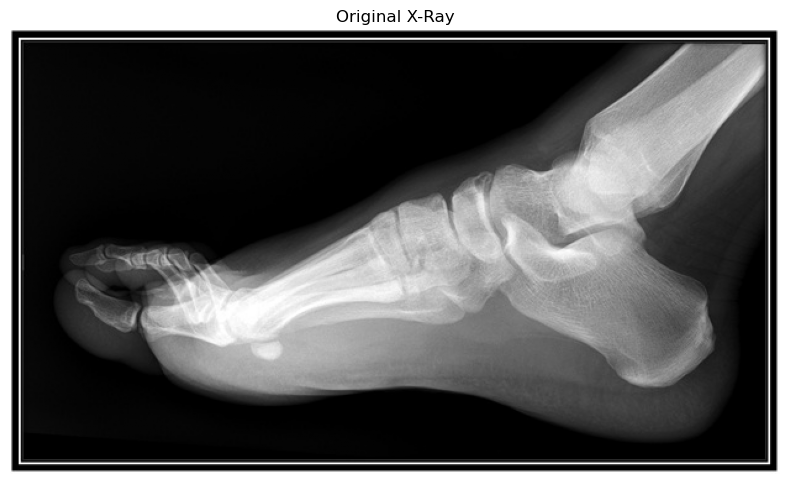

In [28]:
img = load_image('../images/task2/x-ray_bone.jpg')  
gray = to_grayscale(img)
print_analysis(gray, "X-Ray Image")
show_images_row([gray], ["Original X-Ray"], figsize=(8, 6))

## 2. Run Three Pipelines

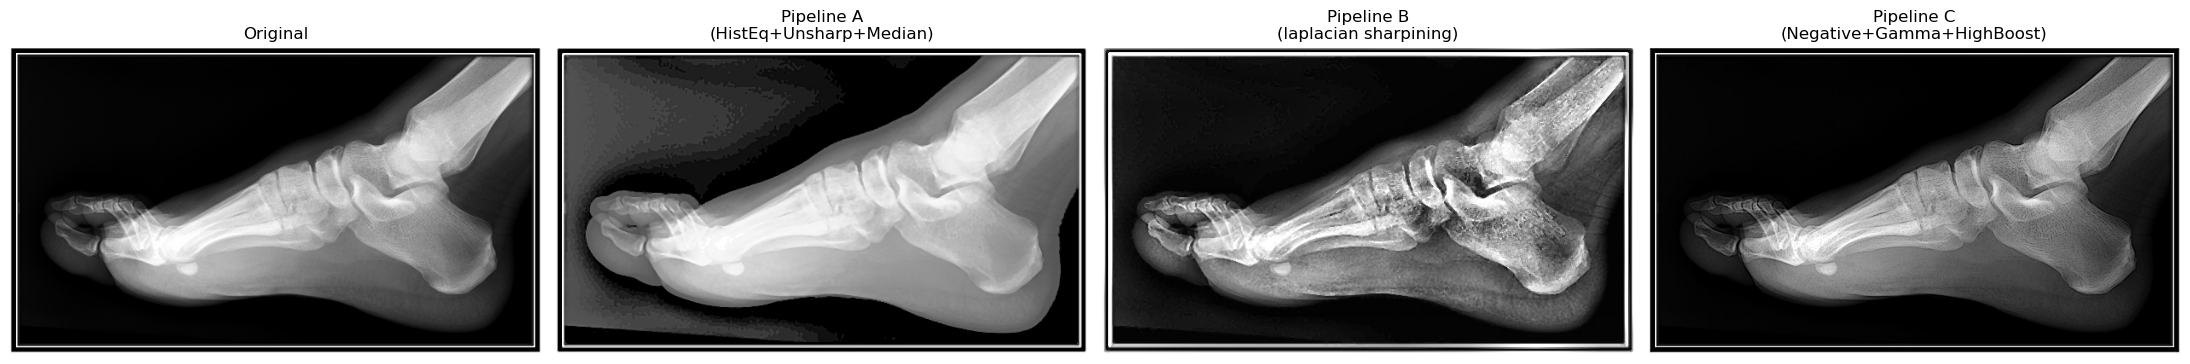

In [33]:
result_a = pipeline_a(gray)
result_b = pipeline_b(gray)
result_c = pipeline_c(gray)

show_images_row(
    [gray, result_a, result_b, result_c],
    ["Original", "Pipeline A\n(HistEq+Unsharp+Median)",
     "Pipeline B\n(laplacian sharpining)",
     "Pipeline C\n(Negative+Gamma+HighBoost)"],
    figsize=(22, 6)
)

## 3. Compare Metrics

In [30]:
print(f"{'Pipeline':<15} {'Contrast (σ)':<15} {'Mean':<10} {'PSNR vs Original':<18}")
print("-" * 58)
for name, result in [("Pipeline A", result_a), ("Pipeline B", result_b), ("Pipeline C", result_c)]:
    contrast = np.std(result.astype(np.float64))
    mean_val = np.mean(result)
    psnr = compute_psnr(gray, result)
    print(f"{name:<15} {contrast:<15.2f} {mean_val:<10.2f} {psnr:<18.2f} dB")

Pipeline        Contrast (σ)    Mean       PSNR vs Original  
----------------------------------------------------------
Pipeline A      82.84           104.19     15.05              dB
Pipeline B      78.20           80.05      15.69              dB
Pipeline C      69.02           54.98      21.69              dB


## 4. Histogram Comparison

C:\Users\ahmed\AppData\Local\Temp\ipykernel_14936\2304793656.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.hist(img_data.ravel(), 256, [0, 256], color='black')


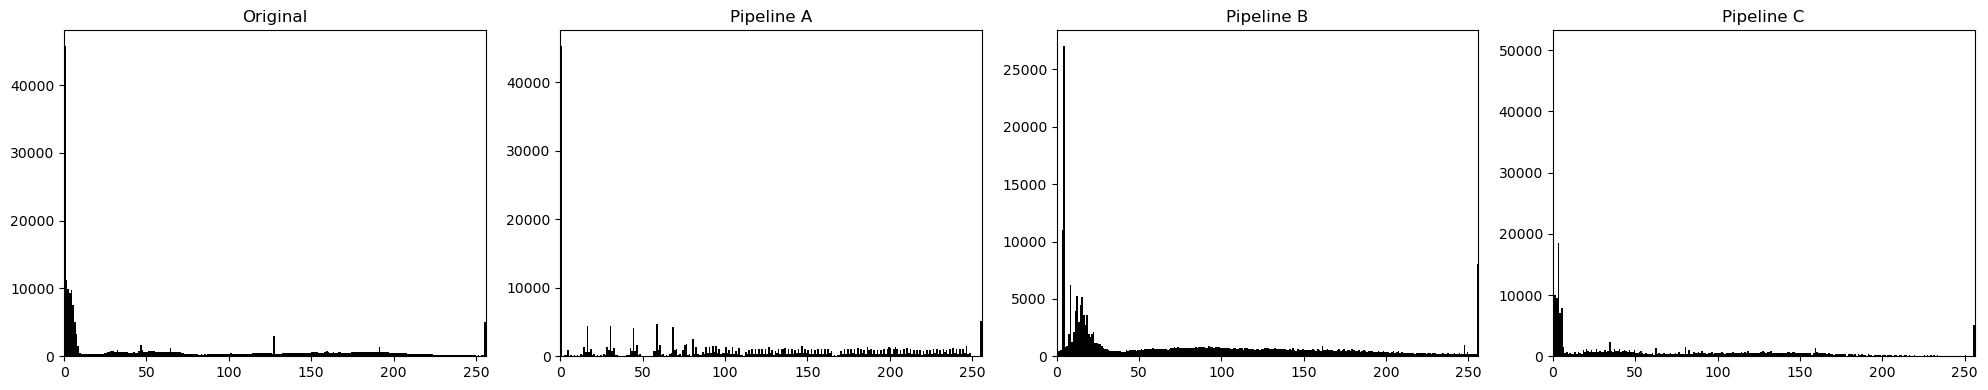

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, img_data, title in zip(axes, [gray, result_a, result_b, result_c],
                                ["Original", "Pipeline A", "Pipeline B", "Pipeline C"]):
    ax.hist(img_data.ravel(), 256, [0, 256], color='black')
    ax.set_title(title)
    ax.set_xlim([0, 256])
plt.tight_layout()
plt.show()

## 5. Save Results

In [32]:
os.makedirs('../outputs/task2', exist_ok=True)
cv2.imwrite('../outputs/task2/pipeline_a.png', result_a)
cv2.imwrite('../outputs/task2/pipeline_b.png', result_b)
cv2.imwrite('../outputs/task2/pipeline_c.png', result_c)
print("✅ Saved to outputs/task2/")

✅ Saved to outputs/task2/
